<a href="https://colab.research.google.com/github/shonnvs-code/Team4-A1-BA820-Project/blob/main/M4_FILES/Shon_Shaju_ProjectM4_Q2_BA820_Team_4_Childcare_Costs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Childcare Costs Dataset**
<BR>
Name:Shon Shaju
<br>
Session & team: A1 & Team 4
<br>


# **1. Executive Summary**

Childcare isn't just a family issue; it’s a major economic factor. In the U.S., childcare is often one of the biggest expenses for a household, sometimes costing between 8.9% and 16% of a family's income, in many places, that is more than rent!

Research shows that when prices go up, parents (especially mothers) are often forced to leave the workforce. This project looks beyond just "average prices" to understand the diverse childcare markets across the U.S. We want to understand how costs relate to income, employment, and local economies so policymakers and employers can make better decisions.

# **2.Question under analysis**

Q2.How do U.S. counties cluster into distinct childcare market types based on pricing structure and affordability pressure, and how do these market types differ in maternal labor force participation? Specifically, do clusters exist where maternal labor participation remains high despite extreme childcare cost-to-income ratios, or where participation remains low even at moderate cost levels?

# **3.Loading Data**

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [10]:
childcare = pd.read_csv('/content/drive/MyDrive/childcare_costs.csv')
counties  = pd.read_csv('/content/drive/MyDrive/counties.csv')

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)
childcare.head()


childcare shape: (34567, 61)
counties shape: (3144, 4)


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [11]:
# mereging both the data sets
df = childcare.merge(counties, on="county_fips_code", how="left")
df

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34562,56045,2014,3.60,5.36,2.28,2.4,4.8,0.6,75.9,74.8,...,112.94,147.36,120.38,123.99,110.71,110.71,111.47,Weston County,Wyoming,WY
34563,56045,2015,5.16,7.86,3.16,4.2,7.6,1.6,73.2,82.0,...,110.89,140.36,118.77,118.77,110.89,110.89,110.89,Weston County,Wyoming,WY
34564,56045,2016,3.61,4.67,2.79,3.4,4.5,2.6,69.7,68.1,...,108.85,133.37,117.16,113.55,114.10,111.07,110.31,Weston County,Wyoming,WY
34565,56045,2017,2.24,2.64,1.95,2.3,2.8,2.0,71.4,63.6,...,106.81,126.38,115.55,108.32,117.30,111.26,109.74,Weston County,Wyoming,WY


# **4.EDA**

## 4.1 Prelimanary EDA

Exploratory analysis is conducted on the full set of counties for 2018.

In [12]:
income_col = "mhi_2018"
maternal_lfp_col = "flfpr_20to64_under6"

center_cols = ["mc_infant", "mc_toddler", "mc_preschool"]
family_cols = ["mfcc_infant", "mfcc_toddler", "mfcc_preschool"]
needed_cols = [income_col, maternal_lfp_col] + center_cols + family_cols
for c in needed_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    else:
        raise KeyError(f"Missing column in df: {c}")
#  Average childcare prices (weekly)
df["center_avg"] = df[center_cols].mean(axis=1)
df["family_avg"] = df[family_cols].mean(axis=1)
df["overall_price_avg_weekly"] = df[["center_avg", "family_avg"]].mean(axis=1)

In [13]:
# 3) Structural pricing features
df["infant_preschool_ratio_center"] = df["mc_infant"] / df["mc_preschool"]
df["infant_preschool_ratio_family"] = df["mfcc_infant"] / df["mfcc_preschool"]

df["center_minus_family"] = df["center_avg"] - df["family_avg"]
df["center_over_family"] = df["center_avg"] / df["family_avg"]


In [14]:
# Affordability ratios (unit-consistent + interpretable)
# Original (weekly price / annual income) — tiny numbers
df["afford_ratio_weekly_over_annual_income"] = df["overall_price_avg_weekly"] / df[income_col]

# Better: weekly childcare / weekly income
df["weekly_income"] = df[income_col] / 52
df["afford_ratio_weekly"] = df["overall_price_avg_weekly"] / df["weekly_income"]

# Best for reporting: annualized childcare / annual income
df["annual_childcare_cost"] = df["overall_price_avg_weekly"] * 52
df["afford_ratio_annual"] = df["annual_childcare_cost"] / df[income_col]

# percent versions
df["afford_pct_weekly"] = 100 * df["afford_ratio_weekly"]
df["afford_pct_annual"] = 100 * df["afford_ratio_annual"]

summary_cols = [
    income_col,
    maternal_lfp_col,
    "overall_price_avg_weekly",
    "afford_ratio_annual",
    "afford_pct_annual",
    "infant_preschool_ratio_center",
    "center_minus_family",
    "center_over_family"
]

display(df[summary_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
mhi_2018,34567.0,50446.777363,13279.833788,19841.920000,41839.215000,48505.600000,56201.450000,136268.000000
flfpr_20to64_under6,34567.0,68.821409,11.758088,0.000000,62.600000,69.600000,76.100000,100.000000
overall_price_avg_weekly,23634.0,120.823587,37.189196,23.603333,95.073333,113.547500,136.288333,376.913333
afford_ratio_annual,23634.0,0.126379,0.030848,0.027841,0.104858,0.123544,0.143457,0.353783
afford_pct_annual,23634.0,12.637925,3.084767,2.784106,10.485793,12.354417,14.345732,35.378250
infant_preschool_ratio_center,23593.0,1.183428,0.109648,0.694021,1.111396,1.162294,1.225100,2.300000
center_minus_family,23342.0,24.484032,20.621476,-90.900000,11.666667,20.200000,31.450000,165.333333
center_over_family,23342.0,1.219410,0.146318,0.272800,1.118728,1.205425,1.298555,2.733333


### 4.1.1 Distribution of Childcare Affordability

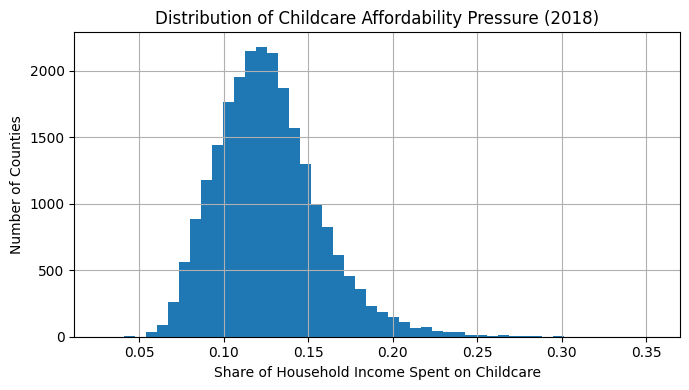

In [15]:
plt.figure(figsize=(7,4))
df["afford_ratio_annual"].dropna().hist(bins=50)
plt.title("Distribution of Childcare Affordability Pressure (2018)")
plt.xlabel("Share of Household Income Spent on Childcare")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()


Most counties cluster around spending 10–15% of household income on childcare, with a long right tail where costs exceed 30% in the most expensive areas.

### 4.1.2 EDA of Childcare Costs, Affordability, and Maternal Labor Force Participation

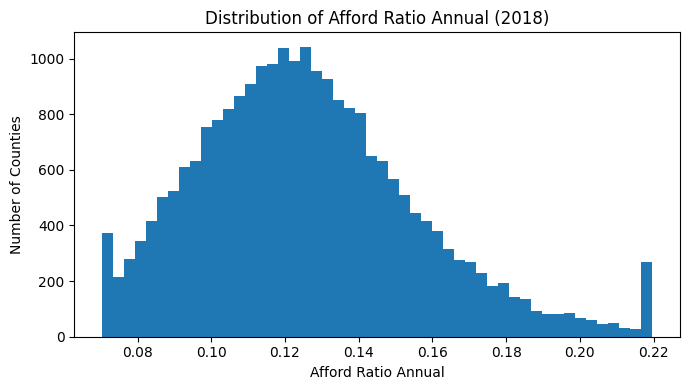

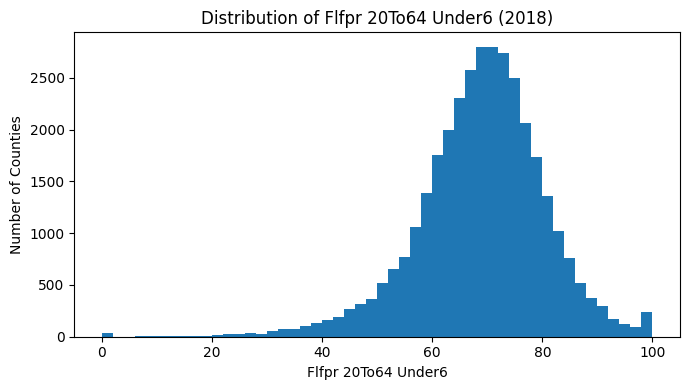

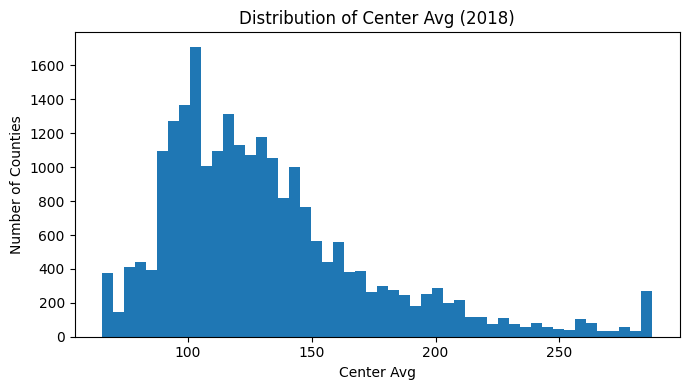

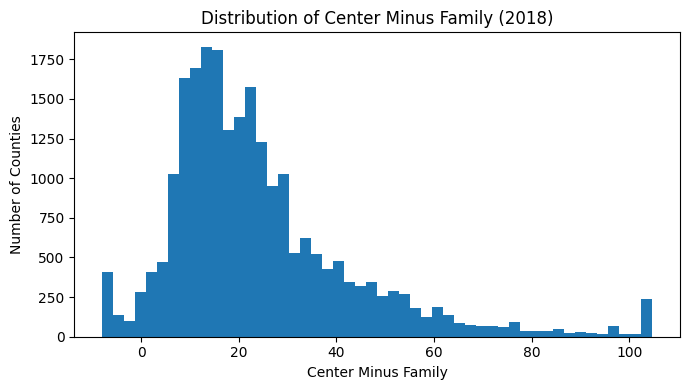

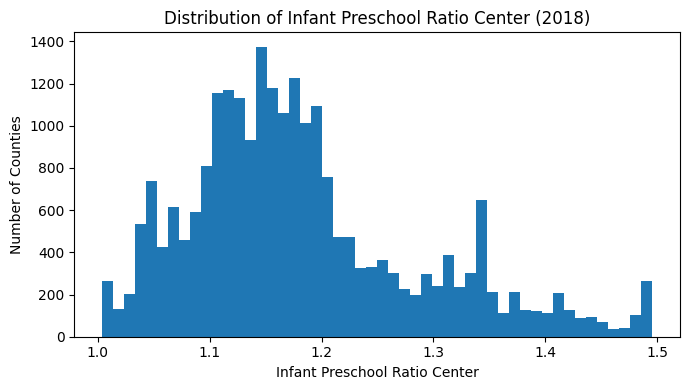

In [16]:
aff_col = "afford_ratio_annual" if "afford_ratio_annual" in df.columns else "afford_ratio"
eda_cols_keep = [
    aff_col,
    maternal_lfp_col,
    "center_avg",
    "center_minus_family",
    "infant_preschool_ratio_center"
]

eda_cols_keep = [c for c in eda_cols_keep if c in df.columns]

for col in eda_cols_keep:
    plt.figure(figsize=(7,4))

    x = df[col].dropna()


    if col != maternal_lfp_col:
        x = x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))

    plt.hist(x, bins=50)
    plt.title(f"Distribution of {col.replace('_',' ').title()} (2018)")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Number of Counties")
    plt.tight_layout()
    plt.show()


### 4.1.3 Price Difference Between Center- and Family-Based Childcare

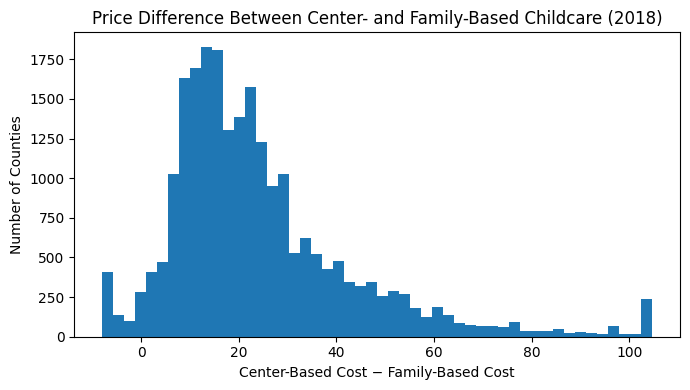

In [17]:
plt.figure(figsize=(7,4))
x = df["center_minus_family"].dropna()

# Light clipping to avoid extreme outliers dominating the histogram
x = x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))

plt.hist(x, bins=50)
plt.title("Price Difference Between Center- and Family-Based Childcare (2018)")
plt.xlabel("Center-Based Cost − Family-Based Cost")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

Most counties exhibit a positive price gap, indicating that center-based childcare is generally more expensive than family-based care, while a long right tail highlights counties with especially large cost premiums.

In [18]:
import matplotlib.pyplot as plt
def clipped_series(s, low=0.01, high=0.99):
    s = s.dropna()
    if len(s) == 0:
        return s
    return s.clip(lower=s.quantile(low), upper=s.quantile(high))

# Choose the right affordability column
burden_col = "afford_ratio_annual" if "afford_ratio_annual" in df.columns else "afford_ratio"

### 4.1.4 Distribution of Childcare Burden (share of income) + median line

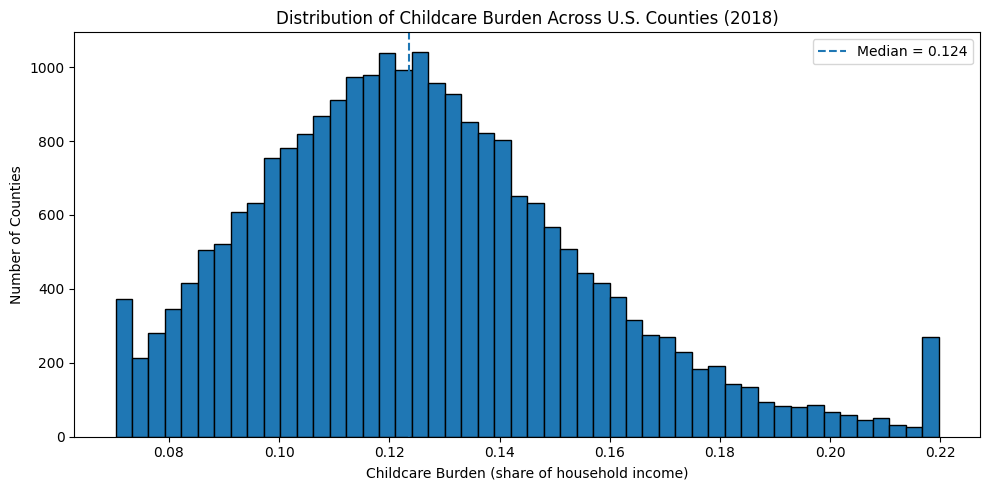

In [19]:
x = clipped_series(df[burden_col])

plt.figure(figsize=(10,5))
plt.hist(x, bins=50, edgecolor="black")
plt.axvline(x.median(), linestyle="--", label=f"Median = {x.median():.3f}")
plt.title("Distribution of Childcare Burden Across U.S. Counties (2018)")
plt.xlabel("Childcare Burden (share of household income)")
plt.ylabel("Number of Counties")
plt.legend()
plt.tight_layout()
plt.show()

Most counties spend around 12% of household income on childcare, but the distribution has a clear right tail, showing that families in some counties face much heavier cost pressure, with childcare taking up over 20% of income.

### 4.1.4 Childcare Burden vs Maternal Labor Force Participation

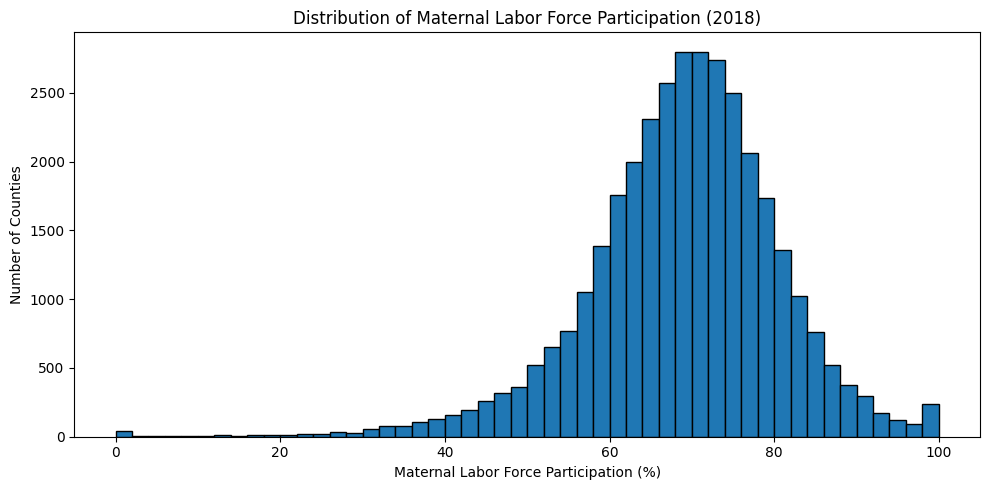

In [20]:
x = clipped_series(df[maternal_lfp_col], low=0.00, high=1.00)  # no clipping needed usually, but safe

plt.figure(figsize=(10,5))
plt.hist(x, bins=50, edgecolor="black")
plt.title("Distribution of Maternal Labor Force Participation (2018)")
plt.xlabel("Maternal Labor Force Participation (%)")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

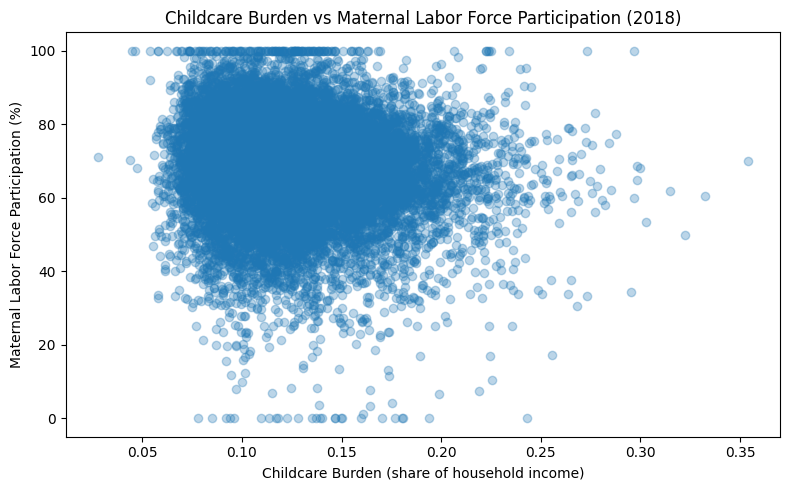

In [21]:
x = df["afford_ratio_annual"]
y = df[maternal_lfp_col]

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3)
plt.xlabel("Childcare Burden (share of household income)")
plt.ylabel("Maternal Labor Force Participation (%)")
plt.title("Childcare Burden vs Maternal Labor Force Participation (2018)")
plt.tight_layout()
plt.show()

The scatter shows a weak but noticeable downward pattern, where counties with higher childcare burden tend to have slightly lower maternal labor force participation. While there is substantial overlap and noise, the overall pattern suggests that higher childcare costs may act as a constraint on mothers’ ability to work.

## 4.2Clustering

In [22]:
cluster_features = [
    "afford_ratio_annual",
    "infant_preschool_ratio_center",
    "infant_preschool_ratio_family",
    "center_minus_family",
    "center_over_family"
]

X_raw = df[cluster_features].copy()

# Preprocessing: impute + scale
prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = prep.fit_transform(X_raw)

print("X shape:", X.shape)

X shape: (34567, 5)


# 5.K means Analysis

### 5.1 Elbow Method

In [23]:
inertias = []

k_values = [2, 3, 4, 5, 6, 7, 8]

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

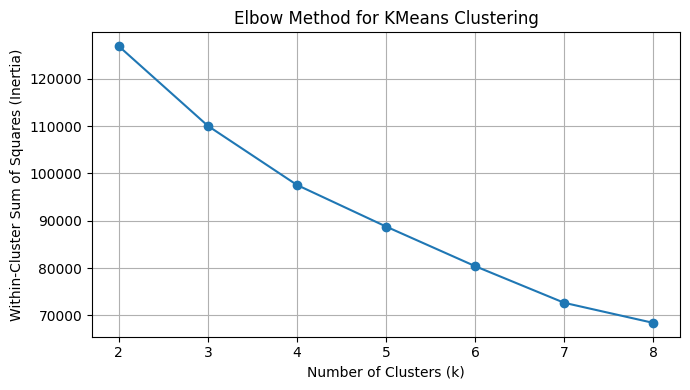

In [24]:
# Plot Elbow curve
plt.figure(figsize=(7,4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for KMeans Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.2 silhouette Method

In [25]:
results = []
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append((k, sil))

results_df = pd.DataFrame(results, columns=["k", "silhouette"]).sort_values("silhouette", ascending=False)
results_df

,k,silhouette
0,3,0.457675
3,6,0.331946
2,5,0.319666
1,4,0.305532


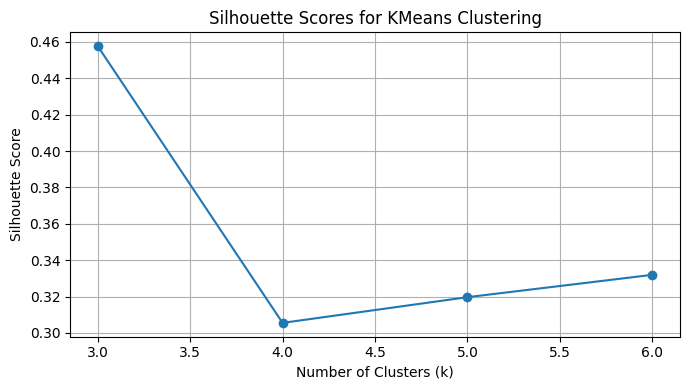

In [26]:
results_df_sorted = results_df.sort_values("k")

plt.figure(figsize=(7,4))
plt.plot(results_df_sorted["k"], results_df_sorted["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for KMeans Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()


Silhouette analysis indicates that k = 3 provides the strongest cluster separation among the values tested, with a substantially higher silhouette score than larger k. In contrast, the elbow method shows a smooth decline in within-cluster variance without a clearly defined inflection point, suggesting no uniquely optimal number of clusters based on inertia alone. Given the exploratory nature of this milestone, k = 3 was selected as it balances quantitative cluster quality with interpretability, while avoiding over-segmentation of counties into weakly separated groups

### 5.3 clustering

In [27]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X)


In [28]:
cluster_summary = (
    df.groupby("kmeans_cluster")[cluster_features]
    .mean()
    .round(3)
)

cluster_summary

,afford_ratio_annual,infant_preschool_ratio_center,infant_preschool_ratio_family,center_minus_family,center_over_family
kmeans_cluster,,,,,
0,0.120,1.147,1.066,16.890,1.172
1,0.155,1.270,1.088,58.469,1.428
2,0.125,1.284,1.231,21.520,1.208


In [29]:
df["kmeans_cluster"].value_counts().sort_index()

,count
kmeans_cluster,
0,27810
1,3959
2,2798


In [30]:
cluster_labels = {
    0: "Low Burden / Balanced Costs",
    1: "Moderate Burden / Center Premium",
    2: "High Burden / High Cost Pressure"
}

df["cluster_label"] = df["kmeans_cluster"].map(cluster_labels)


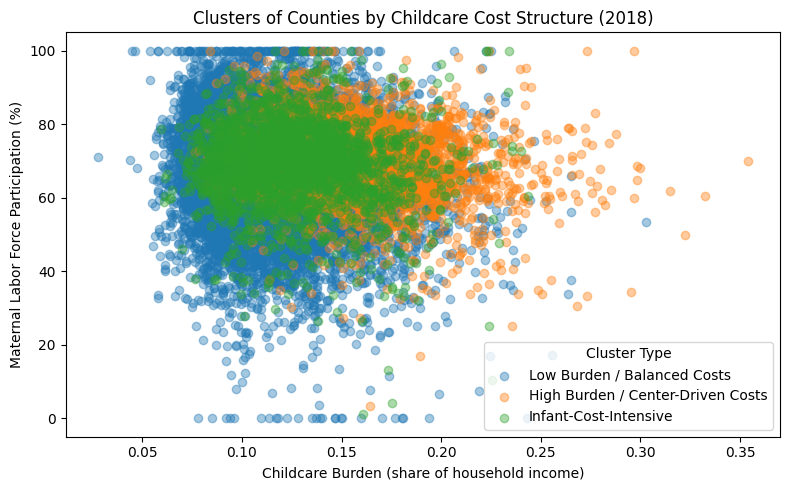

In [31]:
import matplotlib.pyplot as plt

# Define readable labels and colors
cluster_labels = {
    0: "Low Burden / Balanced Costs",
    1: "High Burden / Center-Driven Costs",
    2: "Infant-Cost-Intensive"
}

colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green"
}

plt.figure(figsize=(8,5))

for c in sorted(df["kmeans_cluster"].unique()):
    subset = df[df["kmeans_cluster"] == c]
    plt.scatter(
        subset["afford_ratio_annual"],
        subset[maternal_lfp_col],
        alpha=0.4,
        color=colors[c],
        label=cluster_labels[c]
    )

plt.xlabel("Childcare Burden (share of household income)")
plt.ylabel("Maternal Labor Force Participation (%)")
plt.title("Clusters of Counties by Childcare Cost Structure (2018)")
plt.legend(title="Cluster Type")
plt.tight_layout()
plt.show()


The clustering identifies three childcare cost environments: low-burden balanced markets (blue), high-burden center-driven markets (orange), and infant-cost-intensive markets (green). Clusters differ strongly along childcare burden (x-axis), while maternal labor force participation shows substantial overlap across clusters, suggesting other local factors also influence labor outcomes.

# 6.Hierarchical Clustering Analysis

In [32]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

hier_results = []
k_values = [2, 3, 4, 5, 6, 7, 8]

for k in k_values:
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")  # ward works well with scaled numeric data
    labels = hc.fit_predict(X)
    sil = silhouette_score(X, labels)
    hier_results.append((k, sil))

hier_results_df = pd.DataFrame(hier_results, columns=["k", "silhouette"]).sort_values("k")
hier_results_df


,k,silhouette
0,2,0.419835
1,3,0.401039
2,4,0.242261
3,5,0.250517
4,6,0.256710
5,7,0.271678
6,8,0.279849


### 6.2 silhouette Method

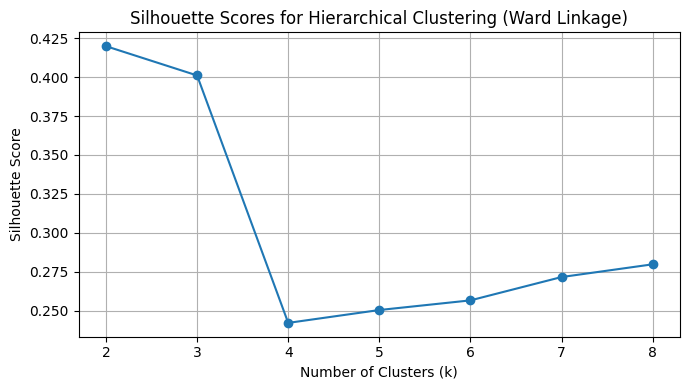

In [33]:
plt.figure(figsize=(7,4))
plt.plot(hier_results_df["k"], hier_results_df["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Hierarchical Clustering (Ward Linkage)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
best_k_hier = hier_results_df.loc[hier_results_df["silhouette"].idxmax(), "k"]
best_sil_hier = hier_results_df["silhouette"].max()

print("Best k (Hierarchical) =", int(best_k_hier))
print("Best silhouette (Hierarchical) =", round(float(best_sil_hier), 4))


Best k (Hierarchical) = 2
Best silhouette (Hierarchical) = 0.4198


In [35]:
hc_final = AgglomerativeClustering(n_clusters=int(best_k_hier), linkage="ward")
df["cluster_hier"] = hc_final.fit_predict(X)

df["cluster_hier"].value_counts().sort_index()


,count
cluster_hier,
0,7894
1,26673


## 6.3 Dendrogram

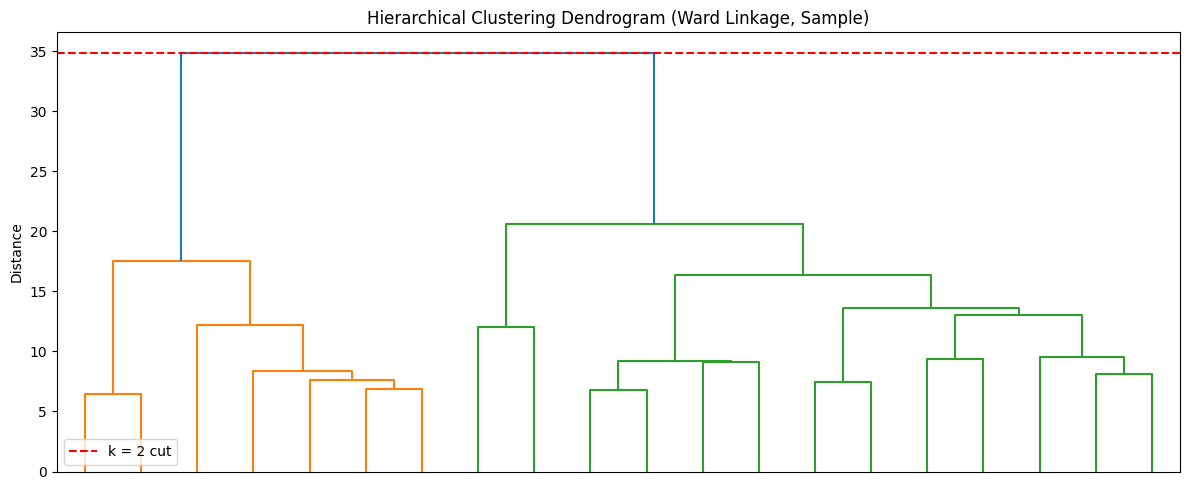

In [36]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Sample for visualization only
sample_n = 400
sample_df = df.sample(n=sample_n, random_state=42)

# Use same features + preprocessing
X_sample = prep.transform(sample_df[cluster_features])

# Ward linkage
Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12,5))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,                 # fewer, clearer merges
    show_leaf_counts=True,
    no_labels=True
)
plt.axhline(y=Z[-(2-1), 2], color="red", linestyle="--", label="k = 2 cut")
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, Sample)")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

# Project M4

# 7.PCA

I used PCA which showed consistent finding as our M3 findings. In M2, exploratory analysis and clustering suggested substantial overlap and weak separation across counties. In M3, PCA showed that most variation was driven by a dominant childcare cost dimension (PC1), indicating that counties lie along a continuous affordability gradient rather than forming naturally distinct groups. Therefore, in M4, PCA helps verify whether clustering reflects meaningful segmentation or is primarily separating extreme high-cost counties. I also use distance in PCA space to identify the top 5% structurally extreme counties, following the M3 approach, to test whether segmentation improves once the distorting tail is isolated.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_m4 = df[df["study_year"] == 2018].copy() if "study_year" in df.columns else df.copy()

# preprocessing on df_m4
X_m4_raw = df_m4[cluster_features].copy().replace([np.inf, -np.inf], np.nan)

prep_m4 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_m4 = prep_m4.fit_transform(X_m4_raw)

# PCA core vs tail (top 5% distance) - Consolidated
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_m4)

dist = np.linalg.norm(X_pca, axis=1)
thr = np.percentile(dist, 95)

core_mask = dist <= thr
tail_mask = dist > thr

df_core = df_m4.loc[core_mask].copy()
df_tail = df_m4.loc[tail_mask].copy()

print("df_m4 shape:", df_m4.shape)
print("Core counties:", df_core.shape[0])
print("Tail counties (top 5%):", df_tail.shape[0])
print("Explained variance ratio (PC1, PC2):", pca2.explained_variance_ratio_)

df_m4 shape: (3142, 81)
Core counties: 2984
Tail counties (top 5%): 158
Explained variance ratio (PC1, PC2): [0.40321184 0.24010416]


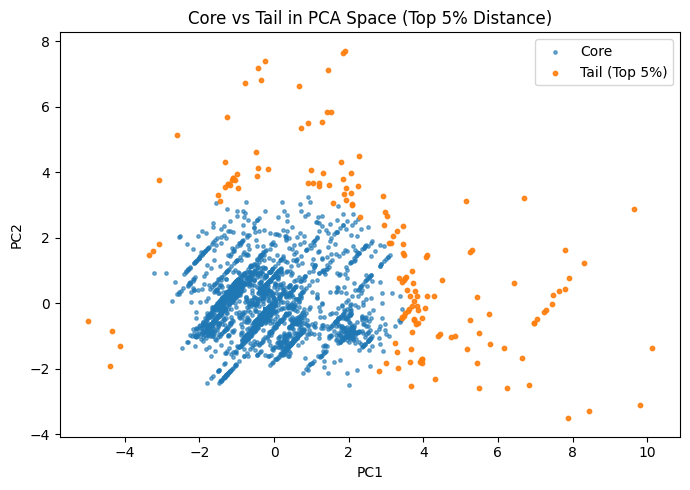

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(X_pca[core_mask,0], X_pca[core_mask,1], s=6, alpha=0.6, label="Core")
plt.scatter(X_pca[tail_mask,0], X_pca[tail_mask,1], s=10, alpha=0.9, label="Tail (Top 5%)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Core vs Tail in PCA Space (Top 5% Distance)")
plt.legend()
plt.tight_layout()
plt.show()

Re-cluster

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_core_raw = df_core[cluster_features].copy().replace([np.inf, -np.inf], np.nan)
X_core = prep_m4.transform(X_core_raw)   # <-- NOW prep_m4 exists and is correct

rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(X_core)
    sil = silhouette_score(X_core, labels)
    sizes = pd.Series(labels).value_counts()
    balance_ratio = sizes.min() / sizes.max()
    rows.append((k, sil, balance_ratio, int(sizes.min()), int(sizes.max())))

pd.DataFrame(rows, columns=["k","silhouette","balance_ratio","min_cluster","max_cluster"])

,k,silhouette,balance_ratio,min_cluster,max_cluster
0,2,0.373155,0.229501,557,2427
1,3,0.295542,0.241794,442,1828
2,4,0.307591,0.262029,403,1538
3,5,0.320773,0.115923,174,1501
4,6,0.342191,0.131030,182,1389
5,7,0.340893,0.196619,221,1124
6,8,0.359592,0.121104,136,1123
7,9,0.371541,0.130224,134,1029
8,10,0.375243,0.080952,85,1050


In [43]:
k = 5
km_core = KMeans(n_clusters=k, n_init=50, random_state=42)
core_labels = km_core.fit_predict(X_core)

df_core["core_cluster_k5"] = core_labels

print("Core silhouette (k=5):", silhouette_score(X_core, core_labels))
print("Cluster sizes:\n", df_core["core_cluster_k5"].value_counts().sort_index())

Core silhouette (k=5): 0.320772969720766
Cluster sizes:
 core_cluster_k5
0     309
1     570
2     430
3    1501
4     174
Name: count, dtype: int64


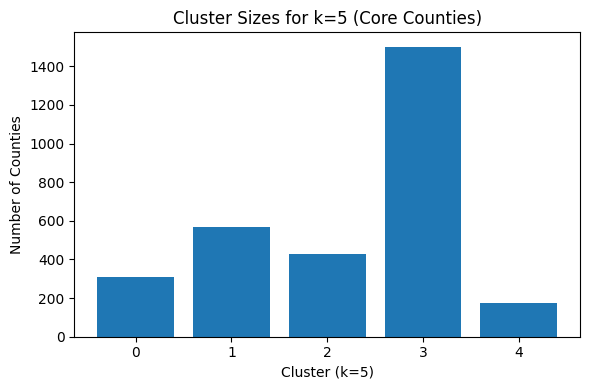

In [44]:
import matplotlib.pyplot as plt

cluster_sizes = df_core["core_cluster_k5"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel("Cluster (k=5)")
plt.ylabel("Number of Counties")
plt.title("Cluster Sizes for k=5 (Core Counties)")
plt.tight_layout()
plt.show()

The PCA visualization shows that counties are distributed along a dominant cost gradient rather than forming clearly separated clusters. The top 5% of counties occupy a structurally extreme region in PCA space, confirming that high-cost outliers drive much of the apparent separation. However, within the core counties, the distribution appears dense and continuous. The k-sweep results further support this interpretation: silhouette scores remain moderate and cluster balance ratios are low across values of k, indicating weak natural segmentation. Together, these findings suggest that U.S. childcare markets are better characterized as a continuous affordability spectrum with a distinct extreme tail, rather than sharply defined market regimes.

#8.Stability Testing

In [45]:
from sklearn.metrics import adjusted_rand_score

seeds = list(range(10))
label_runs = []

for seed in seeds:
    km = KMeans(n_clusters=5, n_init=30, random_state=seed)
    label_runs.append(km.fit_predict(X_core))

ari = np.zeros((len(seeds), len(seeds)))
for i in range(len(seeds)):
    for j in range(len(seeds)):
        ari[i,j] = adjusted_rand_score(label_runs[i], label_runs[j])

ari_df = pd.DataFrame(ari, index=seeds, columns=seeds)
ari_df

,0,1,2,3,4,5,6,7,8,9
0,1.000000,1.000000,0.998021,1.000000,1.000000,0.959226,0.959715,1.000000,0.963093,0.993378
1,1.000000,1.000000,0.998021,1.000000,1.000000,0.959226,0.959715,1.000000,0.963093,0.993378
2,0.998021,0.998021,1.000000,0.998021,0.998021,0.957268,0.957757,0.998021,0.961131,0.991401
3,1.000000,1.000000,0.998021,1.000000,1.000000,0.959226,0.959715,1.000000,0.963093,0.993378
4,1.000000,1.000000,0.998021,1.000000,1.000000,0.959226,0.959715,1.000000,0.963093,0.993378
5,0.959226,0.959226,0.957268,0.959226,0.959226,1.000000,0.999508,0.959226,0.995965,0.965520
6,0.959715,0.959715,0.957757,0.959715,0.959715,0.999508,1.000000,0.959715,0.995472,0.966009
7,1.000000,1.000000,0.998021,1.000000,1.000000,0.959226,0.959715,1.000000,0.963093,0.993378
8,0.963093,0.963093,0.961131,0.963093,0.963093,0.995965,0.995472,0.963093,1.000000,0.969418
9,0.993378,0.993378,0.991401,0.993378,0.993378,0.965520,0.966009,0.993378,0.969418,1.000000


We use k=5 to maintain consistency with the M3 core-county baseline and to balance statistical separation with interpretability. Although k=2 produces a slightly higher silhouette, it yields overly coarse segmentation dominated by cost level. At k=5, the silhouette remains moderate while providing meaningful differentiation in affordability and pricing structure. Importantly, the ARI results show extremely high stability across random seeds, indicating that the k=5 solution is reproducible and not driven by initialization noise.

In [46]:
X_core_raw = df_core[cluster_features].copy().replace([np.inf, -np.inf], np.nan)

pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

X_core_scaled = pipe.fit_transform(X_core_raw)

In [47]:
pca = PCA(n_components=2, random_state=42)
X_core_pca = pca.fit_transform(X_core_scaled)

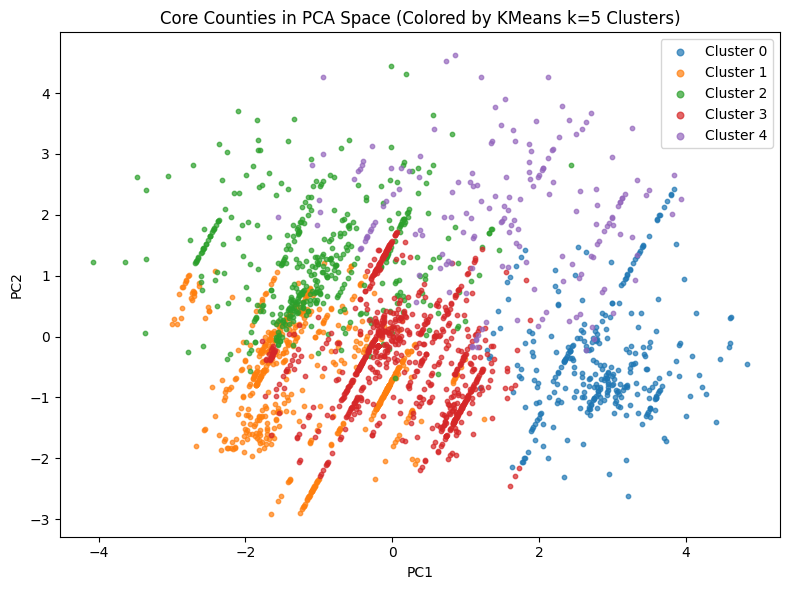

In [48]:
plt.figure(figsize=(8, 6))
clusters = sorted(df_core["core_cluster_k5"].unique())

for c in clusters:
    mask = (df_core["core_cluster_k5"] == c).values
    plt.scatter(X_core_pca[mask, 0], X_core_pca[mask, 1], s=10, alpha=0.7, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Core Counties in PCA Space (Colored by KMeans k=5 Clusters)")
plt.legend(markerscale=1.5)
plt.tight_layout()
plt.show()

The PCA plot colored by the k=5 clusters shows that counties are mainly separated along PC1, the dominant childcare cost dimension. Instead of clear, spherical clusters, the groups appear as segments along a continuous affordability gradient. The moderate silhouette score (~0.32) suggests weak separation, but the high ARI indicates the solution is stable and reproducible. Overall, k=5 captures layered affordability regimes rather than fully distinct market types.

In [49]:
participation_col = maternal_lfp_col # Using the previously defined variable

data_to_plot = [
    df_core.loc[df_core["core_cluster_k5"] == c, participation_col].dropna().values
    for c in sorted(df_core["core_cluster_k5"].unique())
]

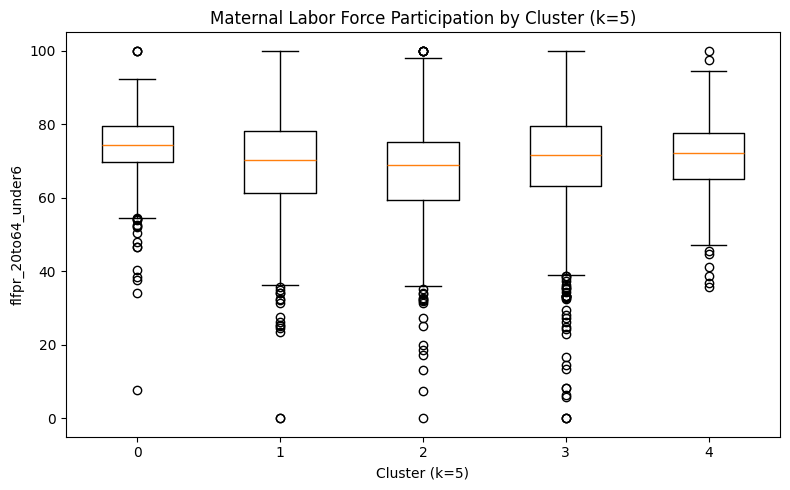

In [50]:
plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=[str(c) for c in sorted(df_core["core_cluster_k5"].unique())])
plt.xlabel("Cluster (k=5)")
plt.ylabel(participation_col)
plt.title("Maternal Labor Force Participation by Cluster (k=5)")
plt.tight_layout()
plt.show()

The boxplot shows strong overlap in maternal labor force participation across the k=5 clusters, with only small differences in median values. This suggests participation does not form clearly distinct regimes and varies widely within clusters. Overall, it reinforces the idea that childcare markets follow a continuous gradient rather than discrete participation-based types.

# 9.Feature Sensitivity

In [51]:
def run_k_sweep(df_in, feat_list, k_values=range(2,8), seed=42):
    Xr = df_in[feat_list].copy().replace([np.inf, -np.inf], np.nan)
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler())])
    Xs = pipe.fit_transform(Xr)

    out=[]
    for k in k_values:
        km = KMeans(n_clusters=k, n_init=30, random_state=seed)
        lab = km.fit_predict(Xs)
        sil = silhouette_score(Xs, lab)
        sizes = pd.Series(lab).value_counts()
        bal = sizes.min()/sizes.max()
        out.append((k, sil, bal))
    return pd.DataFrame(out, columns=["k","silhouette","balance_ratio"])

print("Structure-only")
display(run_k_sweep(df_core, structure_set))

print("Cost-only")
display(run_k_sweep(df_core, cost_set))

print("Socio-only")
display(run_k_sweep(df_core, socio_set))

Structure-only


,k,silhouette,balance_ratio
0,2,0.401162,0.221949
1,3,0.287469,0.269805
2,4,0.308635,0.211772
3,5,0.338608,0.207300
4,6,0.344152,0.155937
5,7,0.359259,0.098177


Cost-only


,k,silhouette,balance_ratio
0,2,0.594434,0.232549
1,3,0.510683,0.190129
2,4,0.531797,0.037015
3,5,0.539702,0.039591
4,6,0.524064,0.035936
5,7,0.524512,0.009675


Socio-only


,k,silhouette,balance_ratio
0,2,0.328139,0.921442
1,3,0.352769,0.349673
2,4,0.317707,0.293781
3,5,0.325001,0.179409
4,6,0.319214,0.219849
5,7,0.321452,0.145631


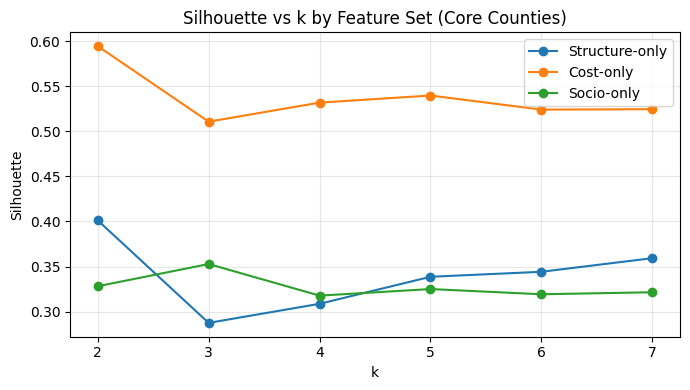

In [52]:
import matplotlib.pyplot as plt

# Run your function
res_struct = run_k_sweep(df_core, structure_set)
res_cost   = run_k_sweep(df_core, cost_set)
res_socio  = run_k_sweep(df_core, socio_set)

plt.figure(figsize=(7,4))
plt.plot(res_struct["k"], res_struct["silhouette"], marker="o", label="Structure-only")
plt.plot(res_cost["k"],   res_cost["silhouette"], marker="o", label="Cost-only")
plt.plot(res_socio["k"],  res_socio["silhouette"], marker="o", label="Socio-only")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k by Feature Set (Core Counties)")
plt.xticks(res_struct["k"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

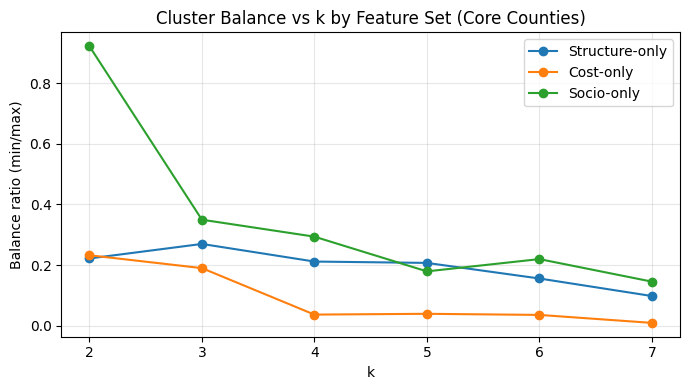

In [53]:
plt.figure(figsize=(7,4))
plt.plot(res_struct["k"], res_struct["balance_ratio"], marker="o", label="Structure-only")
plt.plot(res_cost["k"],   res_cost["balance_ratio"], marker="o", label="Cost-only")
plt.plot(res_socio["k"],  res_socio["balance_ratio"], marker="o", label="Socio-only")
plt.xlabel("k")
plt.ylabel("Balance ratio (min/max)")
plt.title("Cluster Balance vs k by Feature Set (Core Counties)")
plt.xticks(res_struct["k"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

This sensitivity analysis checks whether our clustering results depend on which features we use. When we cluster using only raw cost variables, we get a higher silhouette score but very imbalanced clusters, suggesting that separation is mostly driven by the overall cost gradient and extreme high-cost counties. When we use structure-only or socio-only variables, separation is weaker but clusters are more balanced. Overall, this indicates that pricing structure adds meaningful variation, but none of the feature sets produce clearly distinct market types.

# 10.UMAP

### 10.2 2D UMAP

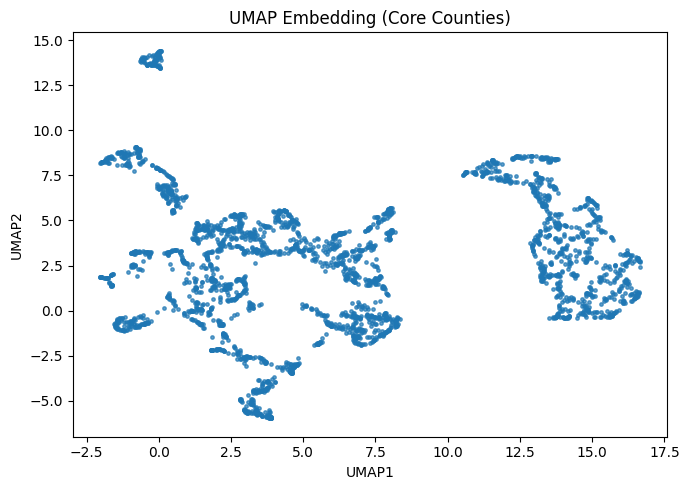

UMAP silhouette (k=5): 0.46995574


In [54]:
!pip -q install umap-learn
import umap.umap_ as umap
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Define feature sets and helper function (re-added as they were previously deleted)
structure_set = [
    "afford_ratio_annual",
    "infant_preschool_ratio_center",
    "infant_preschool_ratio_family",
    "center_minus_family",
    "center_over_family"
]
cost_set = ["mc_infant","mc_toddler","mc_preschool","mfcc_infant","mfcc_toddler","mfcc_preschool"]
socio_set = ["mhi_2018","flfpr_20to64_under6"]

def keep_existing(cols, df_in):
    return [c for c in cols if c in df_in.columns]

# Use structure + socio together for the nonlinear test
umap_features = keep_existing(structure_set + socio_set, df_core)

X_umap_raw = df_core[umap_features].copy().replace([np.inf, -np.inf], np.nan)
pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc", StandardScaler())])
X_umap_scaled = pipe.fit_transform(X_umap_raw)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
Z = reducer.fit_transform(X_umap_scaled)

plt.figure(figsize=(7,5))
plt.scatter(Z[:,0], Z[:,1], s=6, alpha=0.7)
plt.title("UMAP Embedding (Core Counties)")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

labels_umap = KMeans(n_clusters=5, n_init=30, random_state=42).fit_predict(Z)
print("UMAP silhouette (k=5):", silhouette_score(Z, labels_umap))

In [55]:
compare_cols = keep_existing(
    ["afford_ratio_annual","mc_preschool","mfcc_preschool","mhi_2018","flfpr_20to64_under6","pr_p","unr_20to64"],
    df_m4
)

core_med = df_core[compare_cols].median(numeric_only=True)
tail_med = df_tail[compare_cols].median(numeric_only=True)

pd.DataFrame({"core_median": core_med, "tail_median": tail_med, "tail_minus_core": tail_med-core_med})

,core_median,tail_median,tail_minus_core
afford_ratio_annual,0.133068,0.1581,0.025032
mc_preschool,125.000000,200.0000,75.000000
mfcc_preschool,110.000000,143.9650,33.965000
mhi_2018,49582.000000,59255.0000,9673.000000
flfpr_20to64_under6,71.500000,74.5500,3.050000
pr_p,14.800000,13.4500,-1.350000
unr_20to64,5.000000,5.0500,0.050000


In [56]:
df_core["umap_cluster_k5"] = labels_umap

df_core.groupby("umap_cluster_k5")[
    ["afford_ratio_annual","flfpr_20to64_under6"]
].median()

,afford_ratio_annual,flfpr_20to64_under6
umap_cluster_k5,,
0,0.132561,69.80
1,0.135349,70.90
2,0.141325,75.60
3,0.106539,71.20
4,0.135237,69.25


Profiling UMAP-based clusters reveals only modest variation in maternal labor force participation across affordability regimes. While clusters differ in median burden, participation rates remain relatively high even in higher-burden clusters, and lower-burden clusters do not consistently exhibit higher participation. This suggests that maternal labor supply does not map cleanly onto affordability-based market types, and that participation is influenced by additional socioeconomic factors beyond childcare cost pressure alone

### 10.2 3D UMAP

UMAP shape: (2984, 3)


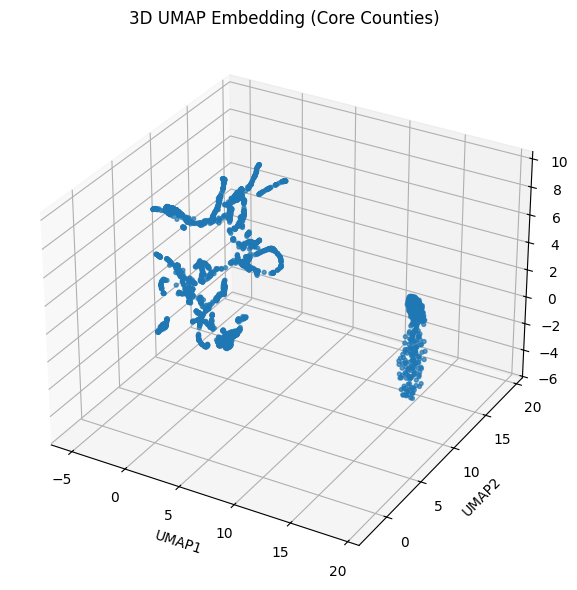

In [57]:
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D

umap_features = cluster_features
# Prepare scaled matrix
X_umap_raw = df_core[umap_features].copy().replace([np.inf, -np.inf], np.nan)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_umap_scaled = pipe.fit_transform(X_umap_raw)

# Run 3D UMAP

reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

Z = reducer.fit_transform(X_umap_scaled)

print("UMAP shape:", Z.shape)   # should be (n_samples, 3)

# 4. 3D Plot

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Z[:,0], Z[:,1], Z[:,2], s=8, alpha=0.7)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_zlabel("UMAP3")
ax.set_title("3D UMAP Embedding (Core Counties)")

plt.tight_layout()
plt.show()

# 11.M3 VS M4

In M3, clustering results were heavily influenced by extreme high-cost counties, raising concerns that segmentation primarily reflected a cost gradient rather than distinct market regimes. In M4, I removed the top 5% extreme counties and re-clustered the core data. The resulting structure remained largely gradient-based, with moderate silhouette scores and imbalanced clusters, confirming that the underlying affordability continuum persists even without extreme outliers. Sensitivity analysis further revealed that cost-only clustering produces artificially strong but highly imbalanced segmentation, while structure-based and socio-based features yield more balanced but weaker separation. Overall, M4 reinforces rather than overturns the M3 conclusion that U.S. childcare markets are best characterized as a continuous affordability spectrum with nonlinear local variation rather than sharply defined regimes.

# 12.Conclusion

This analysis examined whether U.S. counties form distinct childcare market types based on pricing structure and affordability pressure, and whether those clusters differ in maternal labor force participation. PCA revealed a strong overall affordability gradient, with a small group of extreme high-cost counties driving much of the apparent separation. Even after removing these extremes and re-clustering, silhouette scores remained moderate and clusters were somewhat imbalanced, suggesting the data reflects a continuous affordability spectrum rather than clearly defined market types. Feature sensitivity tests showed that cost-only variables create stronger but highly imbalanced clusters, while structure-only and socioeconomic features produce weaker but more balanced segmentation. UMAP confirmed some localized nonlinear variation but did not overturn the broader gradient pattern. Overall, maternal labor participation differences across clusters were modest, indicating that U.S. childcare markets are better characterized as economically stratified along a continuum rather than divided into sharply distinct regimes.